In [4]:
import numpy as np
import matplotlib.pyplot as plt
from prysm.x.dm import DM
from prysm import coordinates, geometry
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from poi.influence_funcs import gaussian_influence_function

# Define the Deformable Mirror

In [3]:
Npup = 512
nact = 34
act_pitch = 0.5
samples_per_act = 8
sampling_pitch = act_pitch / samples_per_act

x, y = coordinates.make_xy_grid(Npup, dx=sampling_pitch)
rho, _ = coordinates.cart_to_polar(x, y)
influence_func = gaussian_influence_function(rho, sampling_pitch)

dm = DM(influence_func, Nout=Npup, Nact=nact, sep=samples_per_act)

# Define a Simple Coronagraph with Aberration

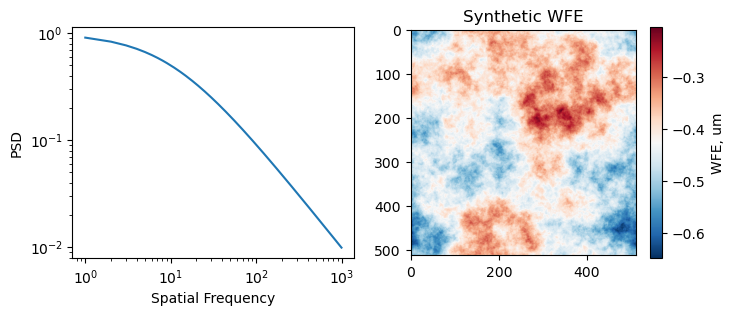

In [ ]:
# Set up a PSD WFE
nu = np.arange(1,1000,1)
psd = abc_psd(nu, a=1, b=10, c=1)

# Just picked ABC values until it looked about right
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

plt.figure(figsize=[8,3])
plt.subplot(121)
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.subplot(122)
plt.title("Synthetic WFE")
plt.imshow(z, cmap="RdBu_r")
plt.colorbar(label="WFE, um")
plt.show()

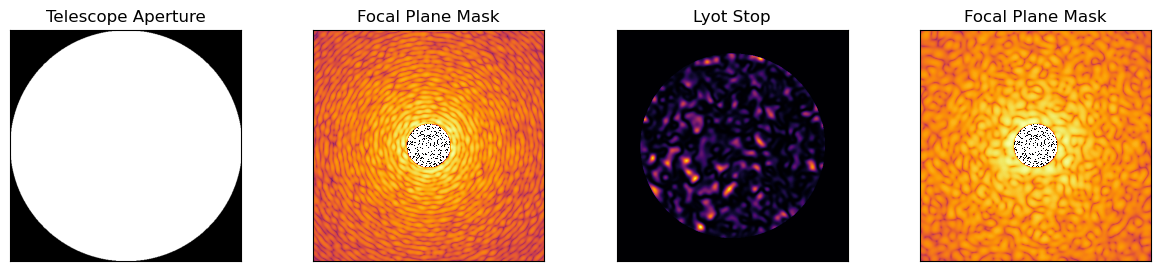

In [26]:
from prysm.propagation import focus_fixed_sampling
from matplotlib.colors import LogNorm

# Parameters
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns

# Set up Pupil
x, y = coordinates.make_xy_grid(Npup, diameter=2)
r, t = coordinates.cart_to_polar(x, y)
A = geometry.circle(1, r)
LS = geometry.circle(0.8, r)

# Set up Focal Plane
u, v = coordinates.make_xy_grid(Npup, dx=dx_img) # assume L/D
rho, th = coordinates.cart_to_polar(u, v)
fpm = 1-geometry.circle(50, rho)

wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

lyot = focus_fixed_sampling(focal * fpm,
                             input_dx=dx_img, # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=Dpup / wvfnt.shape[0], # microns
                             output_samples=wvfnt.shape[0])

coro = focus_fixed_sampling(lyot * LS,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

focal_intensity = np.abs(focal)**2

plt.figure(figsize=[15, 3])
plt.subplot(141)
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(142)
plt.title("Focal Plane Mask")
plt.imshow(np.abs(focal)**2 * fpm, cmap="inferno", norm=LogNorm())
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(143)
plt.title("Lyot Stop")
plt.imshow(np.abs(lyot)**2 * LS, cmap="inferno")
plt.xticks([],[])
plt.yticks([],[])
plt.subplot(144)
plt.title("Focal Plane Mask")
plt.imshow(np.abs(coro)**2 * fpm, cmap="inferno", norm=LogNorm())
plt.xticks([],[])
plt.yticks([],[])
plt.show()